In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Desktop\Adam\NLP Projects\AIOps Incident Triage\tickets_clean.csv")

In [3]:
# Exploring the Data
df.head()

,ticket_id,created_date,resolved_date,category,sub_category,priority,status,subject,description,resolution,product_service,department,satisfaction_rating,time_to_resolution_hours,text_length
0,TKT-10001,2025-05-09 00:00,2025-05-09 02:12,Access/Permissions,Account Lockout,Critical,Resolved,Account locked after password change,"hi there, changed my password yesterday and no...",Account lockout was caused by mobile devices t...,Azure AD,Logistics,4.0,2.2,296
1,TKT-10002,2023-09-13 00:00,2023-09-13 07:48,Security,Malware,Critical,Closed,USB drive triggered security alert,plugged in a usb drive i got at a conference a...,USB contained autorun malware that was caught ...,Palo Alto Cortex,Customer Support,3.0,7.8,245
2,TKT-10003,2025-01-28 00:00,2025-01-28 03:12,Hardware,Desktop,Critical,Closed,Need more RAM — computer too slow with current...,my macbook pro m3 only has 8gb ram and i regul...,Approved RAM upgrade request. Installed additi...,MacBook Pro M3,Product,3.0,3.2,323
3,TKT-10004,2024-10-08 00:00,NaN,Cloud/Infrastructure,VM,Critical,Open,Need to resize VM — running out of resources,our staging vm needs to be upgraded — currentl...,NaN,Azure Blob Storage,Human Resources,NaN,NaN,264
4,TKT-10005,2025-01-11 00:00,2025-01-12 19:06,Hardware,Desktop,Low,Closed,Need more RAM — computer too slow with current...,my dell precision 5570 only has 8gb ram and i ...,Approved RAM upgrade request. Installed additi...,Dell Precision 5570,Customer Support,3.0,43.1,280


In [ ]:
# Check Missing Values
Missings = (df.isna().sum() / len(df)) * 100
print(f"The Dataset has Missing Values at each row\n{Missings.round(2)}")


The Dataset has Missing Values at each row
ticket_id                    0.00
created_date                 0.00
resolved_date               24.99
category                     0.00
sub_category                 0.00
priority                     0.00
status                       0.00
subject                      0.00
description                  0.00
resolution                  24.99
product_service              0.00
department                   0.00
satisfaction_rating         24.99
time_to_resolution_hours    24.99
text_length                  0.00
created_dayofweek            0.00
is_weekend                   0.00
text                         0.00
dtype: float64%


In [5]:
# Convert to datetime
df['created_date'] = pd.to_datetime(df['created_date'])
# Extract useful tabular features from the timestamp
df['created_dayofweek'] = df['created_date'].dt.dayofweek
df['is_weekend'] = df['created_dayofweek'].isin([4, 5]).astype(int) 


In [6]:
df["created_date"] = pd.to_datetime(df["created_date"])
# Converting some Categorical Variables to categorical data type
df["category"] = df["category"].astype("category")
df["sub_category"] = df["sub_category"].astype("category")
df["priority"] = df["priority"].astype("category")
df["status"] = df["status"].astype("category")
# Converting created_hour and created_dayofweek to int64 instead of int32
df["created_dayofweek"] = df["created_dayofweek"].astype("int64")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9980 entries, 0 to 9979
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ticket_id                 9980 non-null   object        
 1   created_date              9980 non-null   datetime64[ns]
 2   resolved_date             7486 non-null   object        
 3   category                  9980 non-null   category      
 4   sub_category              9980 non-null   category      
 5   priority                  9980 non-null   category      
 6   status                    9980 non-null   category      
 7   subject                   9980 non-null   object        
 8   description               9980 non-null   object        
 9   resolution                7486 non-null   object        
 10  product_service           9980 non-null   object        
 11  department                9980 non-null   object        
 12  satisfaction_rating 

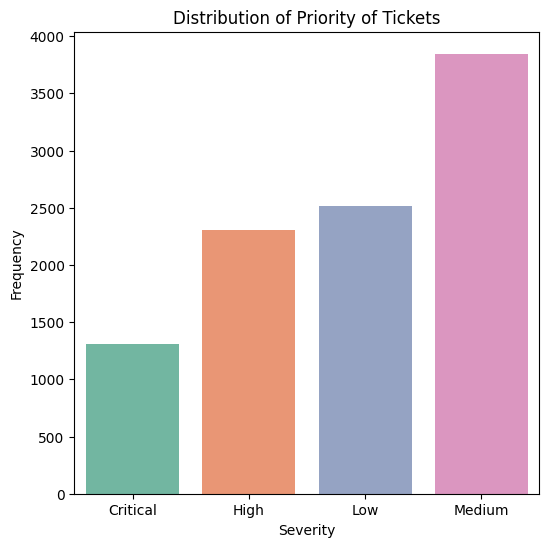

In [8]:
# Visualizing the Distribuition of our Target Variable (time_to_resolution_hours)
plt.figure(figsize=(6,6))
sns.countplot(data=df , x=df["priority"] , palette="Set2" , hue= df["priority"])
plt.title("Distribution of Priority of Tickets")
plt.xlabel("Severity")
plt.ylabel("Frequency")
plt.show()

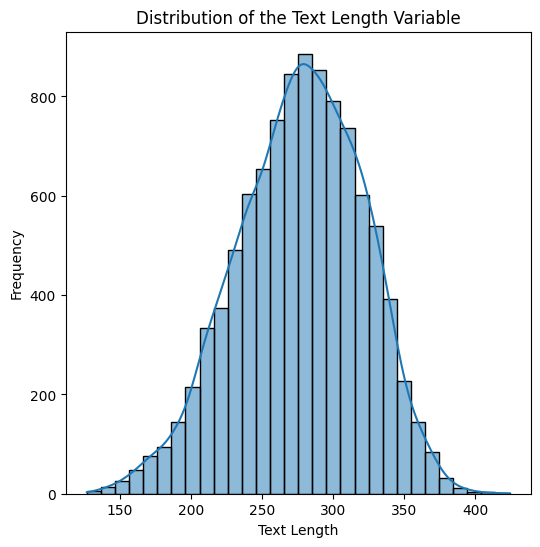

In [9]:
# Numerical Variable Distribution in my Feature Matrix (text_length)
plt.figure(figsize=(6,6))
sns.histplot(data= df["text_length"] , bins= 30 , kde= True)
plt.title("Distribution of the Text Length Variable")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


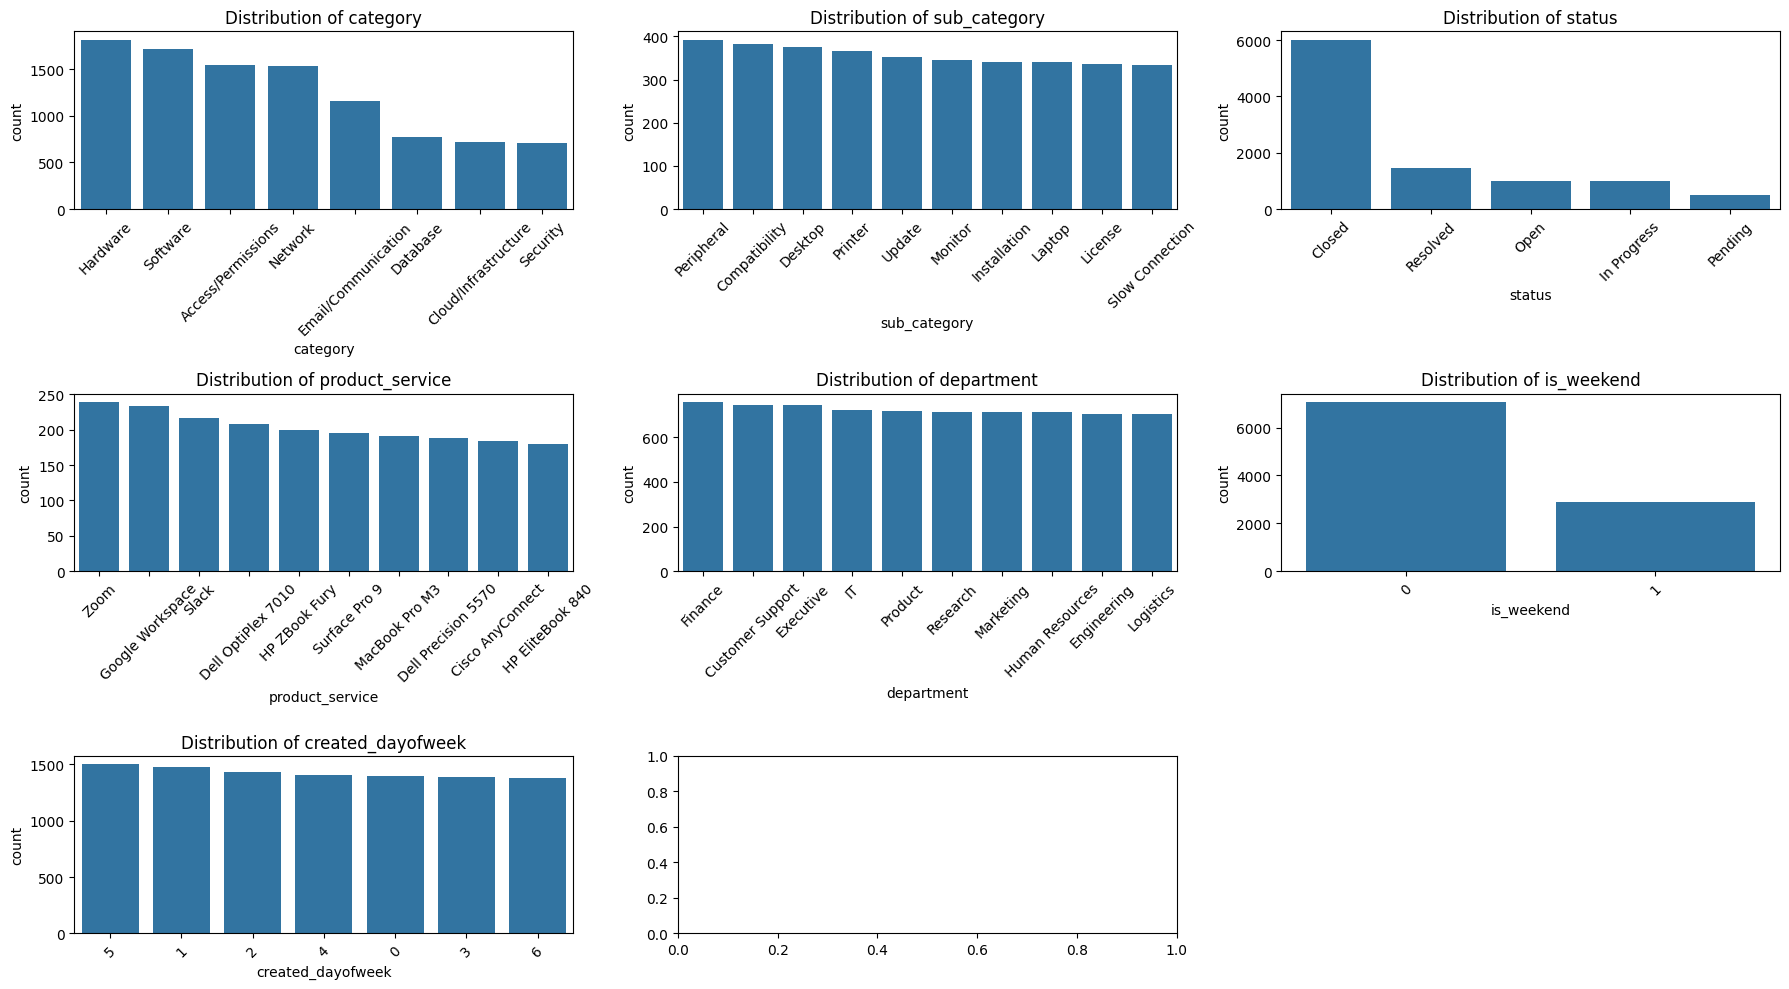

In [11]:
# Categorical Variables Distribution 
categorical_cols = [
    "category",
    "sub_category",
    "status",
    "product_service",
    "department",
    "is_weekend",
    "created_dayofweek"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 10))

for col, ax in zip(categorical_cols, axes.flat):
    top_cats = df[col].value_counts().nlargest(10).index
    sns.countplot(data=df, x=col, ax=ax , order= top_cats)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=45)

plt.delaxes(axes.flat[-1])
plt.tight_layout()
plt.show()

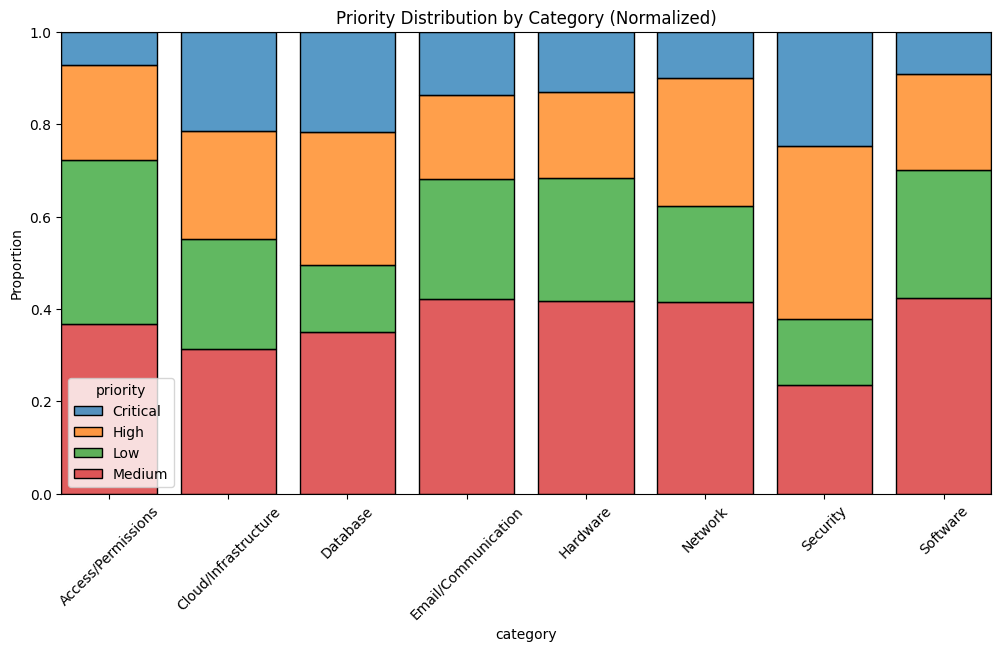

In [12]:
# Proportion of Priority levels across different Categories
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='category', hue='priority', multiple='fill', shrink=0.8)
plt.title('Priority Distribution by Category (Normalized)')
plt.xticks(rotation=45)
plt.ylabel('Proportion')
plt.show()

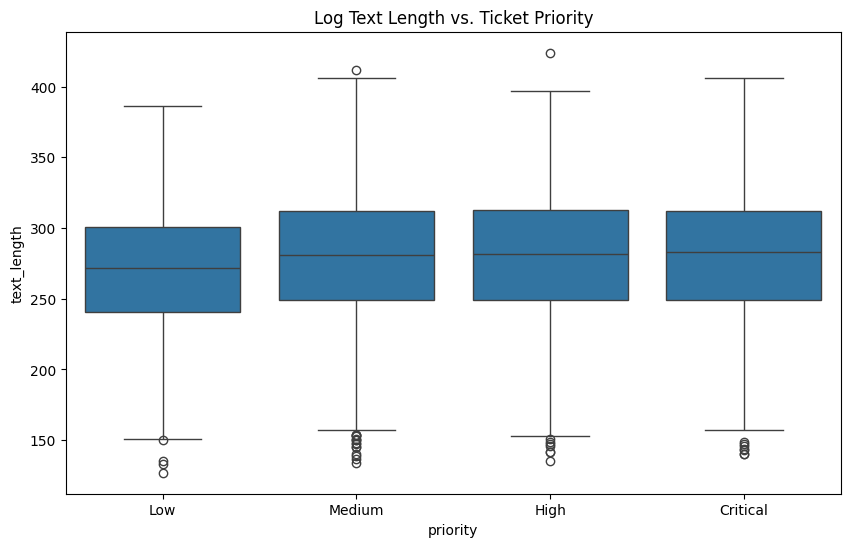

In [14]:
# Text Length vs Priority
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='priority', y='text_length', order=['Low', 'Medium', 'High', 'Critical'])
plt.title('Log Text Length vs. Ticket Priority')
plt.show()

In [15]:
# Temporary mapping for EDA correlation
priority_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

# Apply to a temporary EDA dataframe
df_eda = df.copy()
df_eda['priority_numeric'] = df_eda['priority'].map(priority_mapping)

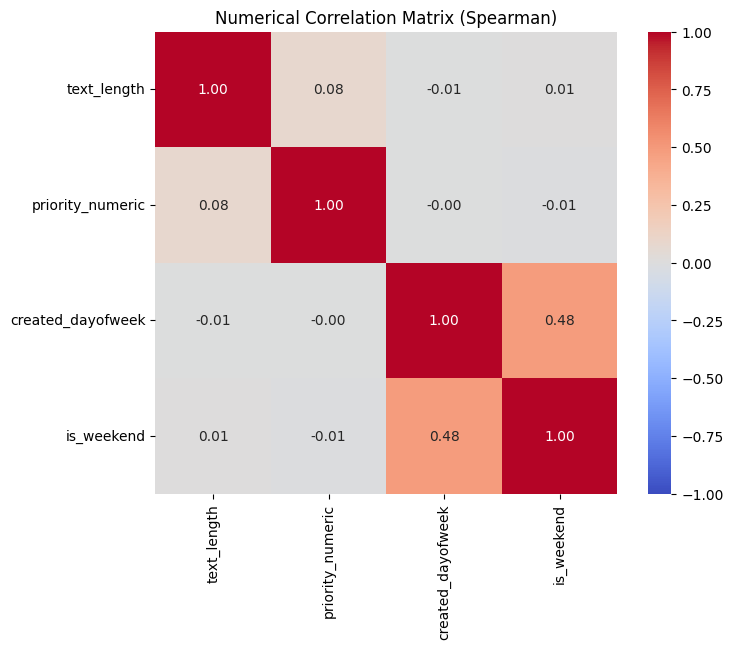

In [16]:
# Add any other numerical columns you have (e.g., historical rolling metrics if engineered)
numerical_cols = ['text_length', 'priority_numeric' , 'created_dayofweek' , 'is_weekend'] 

# Calculate Spearman correlation
num_corr_matrix = df_eda[numerical_cols].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(num_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Numerical Correlation Matrix (Spearman)")
plt.show()

In [17]:
def cramer_V(x , y):
    # Create a Contingency Table
    contingency_table = pd.crosstab(x,y)
    # Performing a chi-square test of independence.
    chi2 , p_value , dof , expected = chi2_contingency(contingency_table)
    # Calculating Cramer V (chi2 / (n * min(r - 1, k - 1))) ** 0.5)
    # n is the number of total obsercations , r is the number of rows , k is the number of columns
    n = contingency_table.sum().sum()
    r , k = contingency_table.shape
    cramer_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1)))

    print(f"Chi_Square: {chi2}")
    print(f"P_Value: {p_value}")
    print(f"Cramer V: {cramer_v}")
    # Interpreting the P-Value
    alpha = 0.05

    if p_value < alpha:
        print("Reject H0: the variables are associated.")
    else:
        print("Fail to reject H0: insufficient evidence of association.")

    return cramer_v , p_value

In [18]:
# Calculating Cramer V for Every Categorical Variable Aganist the Target Variable (priority)
for col in categorical_cols:
    cramer_v , p_value = cramer_V(df[col] , df["priority"])
    print(f"{col}")
    print()

Chi_Square: 574.7506708408083
P_Value: 3.2356207054831926e-108
Cramer V: 0.13855233376987833
Reject H0: the variables are associated.
category

Chi_Square: 2618.9574895971464
P_Value: 0.0
Cramer V: 0.2957592433833047
Reject H0: the variables are associated.
sub_category

Chi_Square: 8.436590666728867
P_Value: 0.7501498055341009
Cramer V: 0.016786400906738934
Fail to reject H0: insufficient evidence of association.
status

Chi_Square: 802.2334314741452
P_Value: 2.1359072107926683e-59
Cramer V: 0.16369087876253707
Reject H0: the variables are associated.
product_service

Chi_Square: 43.132128742194894
P_Value: 0.29901583435262075
Cramer V: 0.03795548527505292
Fail to reject H0: insufficient evidence of association.
department

Chi_Square: 2.283751883655315
P_Value: 0.5156407592203436
Cramer V: 0.015127222285458717
Fail to reject H0: insufficient evidence of association.
is_weekend

Chi_Square: 17.95540552528582
P_Value: 0.4585940091317722
Cramer V: 0.024489037208439205
Fail to reject H0:

In [19]:
# Checking for Multicollinearity between the categorical Variables
association_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=categorical_cols,
    dtype=float)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            association_matrix.loc[col1 , col2] = 1
        else:
            association_matrix.loc[col1 , col2] = cramer_V(df[col1] , df[col2])[0] # i did sliced only the first index beacuse it is the cramer v value
            
association_matrix


Chi_Square: 69860.0
P_Value: 0.0
Cramer V: 1.0
Reject H0: the variables are associated.
Chi_Square: 30.394604579582477
P_Value: 0.3446072441491692
Cramer V: 0.027593258058266734
Fail to reject H0: insufficient evidence of association.
Chi_Square: 67403.60181030974
P_Value: 0.0
Cramer V: 0.9822618153210553
Reject H0: the variables are associated.
Chi_Square: 98.72892799678006
P_Value: 0.2720754253281634
Cramer V: 0.03759308096671511
Fail to reject H0: insufficient evidence of association.
Chi_Square: 7.122269457403308
P_Value: 0.4162613117074141
Cramer V: 0.026714308043608925
Fail to reject H0: insufficient evidence of association.
Chi_Square: 40.915002409423934
P_Value: 0.518520300659089
Cramer V: 0.026139687706062467
Fail to reject H0: insufficient evidence of association.
Chi_Square: 69860.0
P_Value: 0.0
Cramer V: 1.0
Reject H0: the variables are associated.
Chi_Square: 141.42943116012873
P_Value: 0.6363811602119256
Cramer V: 0.059521604664583026
Fail to reject H0: insufficient evide

,category,sub_category,status,product_service,department,is_weekend,created_dayofweek
category,1.000000,1.000000,0.027593,0.982262,0.037593,0.026714,0.026140
sub_category,1.000000,1.000000,0.059522,0.436669,0.064009,0.061764,0.062936
status,0.027593,0.059522,1.000000,0.089106,0.035596,0.019711,0.025844
product_service,0.982262,0.436669,0.089106,1.000000,0.093638,0.085776,0.097439
department,0.037593,0.064009,0.035596,0.093638,1.000000,0.028912,0.036602
is_weekend,0.026714,0.061764,0.019711,0.085776,0.028912,1.000000,1.000000
created_dayofweek,0.026140,0.062936,0.025844,0.097439,0.036602,1.000000,1.000000


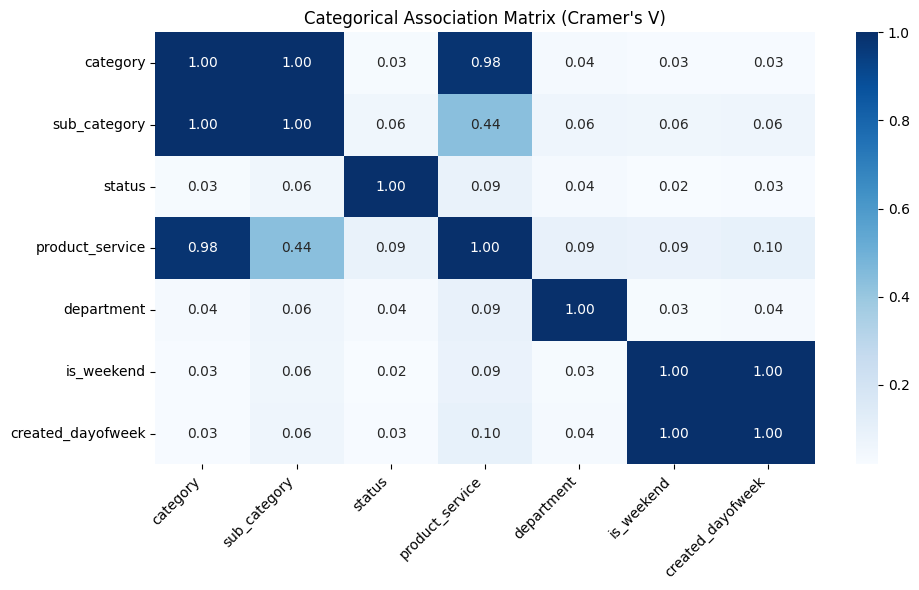

In [20]:
# Plotting the Association Matirx Between our Categorical Variables
plt.figure(figsize=(10,6))
sns.heatmap(association_matrix , cmap= "Blues" , fmt= ".2f" , annot= True)
plt.title("Categorical Association Matrix (Cramer's V)")
plt.xticks(rotation = 45 , ha = "right")
plt.tight_layout()
plt.show()

In [22]:
# Sorting our Data Chornologically
df = df.sort_values("created_date").reset_index(drop=True)
print(f"Dataset Timeline: {df['created_date'].min().strftime('%Y-%m-%d')} to {df['created_date'].max().strftime('%Y-%m-%d')}")

Dataset Timeline: 2023-01-01 to 2025-12-31


In [35]:
daily_priority = df.groupby([df["created_date"].dt.date , "priority"],observed=False).size().unstack(fill_value=0)
daily_priority.head()

priority,Critical,High,Low,Medium
created_date,,,,
2023-01-01,0,3,2,2
2023-01-02,2,5,3,6
2023-01-03,2,1,4,1
2023-01-04,1,2,3,1
2023-01-05,2,2,0,6


C:\Users\Dell\AppData\Local\Temp\ipykernel_19216\1277563754.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Priority")


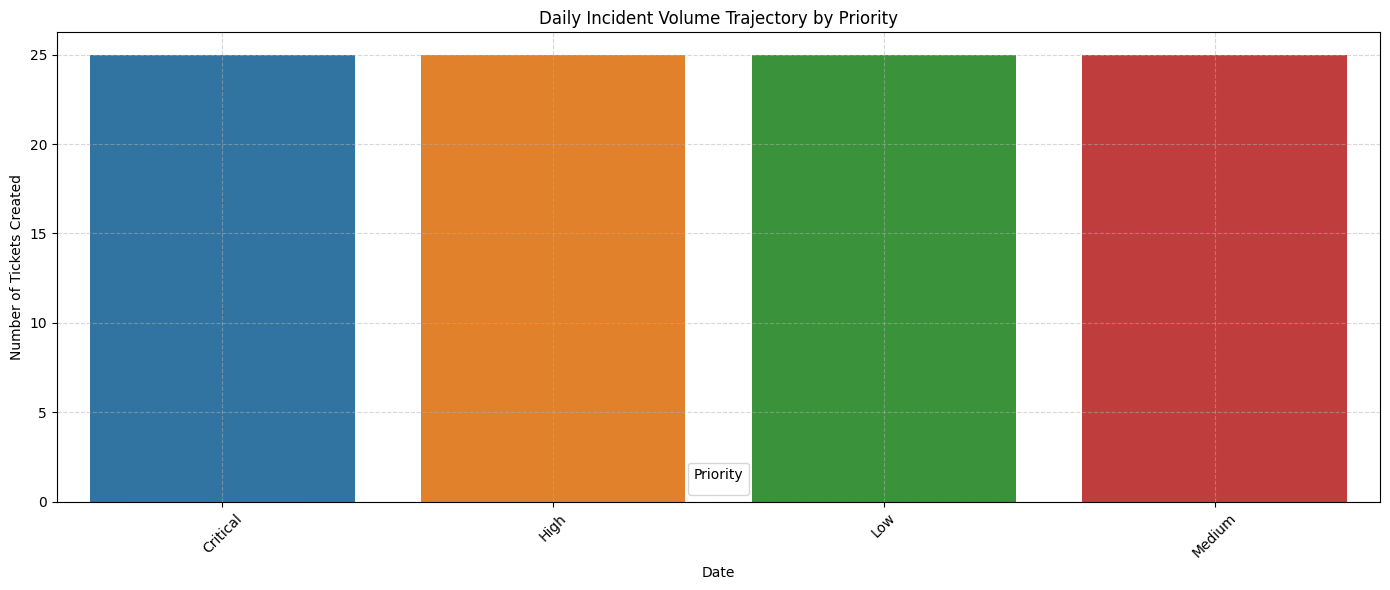

In [44]:
plt.figure(figsize=(14, 6))
sns.countplot(data= daily_priority , stat= 'percent')
plt.title("Daily Incident Volume Trajectory by Priority")
plt.xlabel("Date")
plt.ylabel("Number of Tickets Created")
plt.legend(title="Priority")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

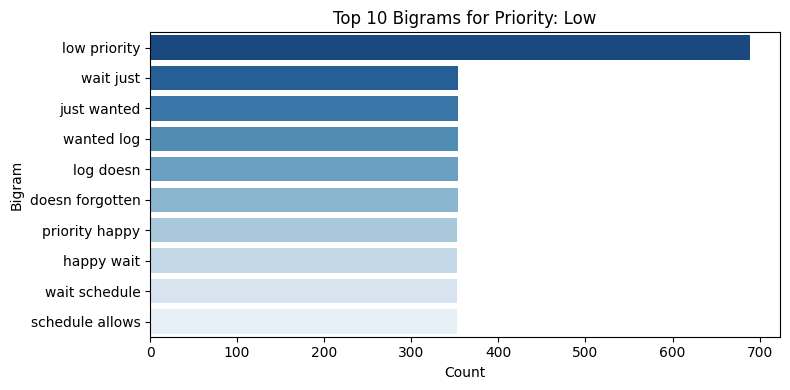

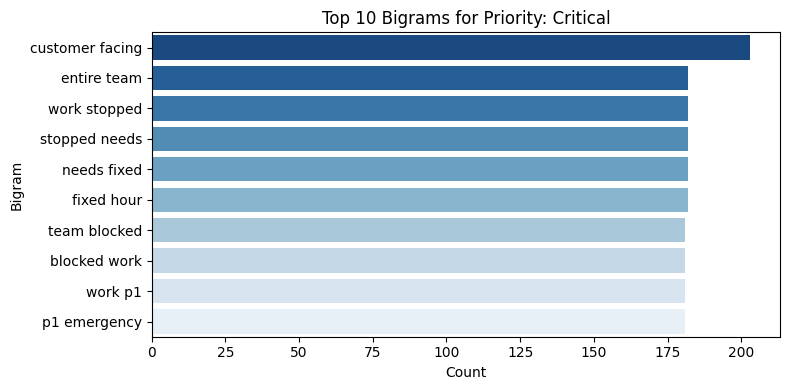

In [55]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_bigrams(df, priority_label, text_col='text', top_k=10):
    """Converting Raw Text into a Matrix of tokens (classic Bag of Words Representation)"""
    
    subset = df[df['priority'] == priority_label][text_col].dropna()
    vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
    bag_of_words = vectorizer.fit_transform(subset)
    
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    df_ngrams = pd.DataFrame(words_freq, columns=['Bigram', 'Count'])
    
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_ngrams, x='Count', y='Bigram', palette='Blues_r' , hue= "Bigram")
    plt.title(f"Top 10 Bigrams for Priority: {priority_label}")
    plt.tight_layout()
    plt.show()

# Compare Low vs Critical priority bi-grams
plot_top_bigrams(df, priority_label='Low')
plot_top_bigrams(df, priority_label='Critical')